# Search-based Test Suite Generation (SuT: `classify_triangle`)

In this exercise, we'll implement a simple **search-based test suite generation** method that searches the input space and keeps tests that improve structural coverage of `classify_triangle`.

In [52]:
def classify_triangle(a: float, b: float, c: float) -> str:
    """Classify a triangle based on three side lengths."""
    sides = sorted([a, b, c])
    x, y, z = sides  # x <= y <= z

    if x <= 0:
        return "invalid"  # Negative or zero length is not allowed

    if x + y <= z:
        return "invalid"  # Violates triangle inequality

    # From here, we have a valid triangle
    if x == y == z:
        return "equilateral"

    is_isosceles = (x == y) or (y == z)
    is_right = (x * x + y * y == z * z)

    if is_isosceles and is_right:
        return "right_isosceles"
    elif is_isosceles:
        return "isosceles"
    elif is_right:
        return "right"
    else:
        return "scalene"

## Summary: test suite generation as a search problem

Test suite generation is reframed as **search over candidate suites** with **coverage as the objective**. The correspondence is:

| Search / optimization | Test suite generation (this exercise) |
| --- | --- |
| **Search space** | All ordered suites of length $l$: each suite is a sequence of $(a,b,c)$ real-valued inputs in a bounded domain (here each side is in [0, 10]). |
| **Candidate solution** | One candidate test suite (e.g. a list of $l$ triples). |
| **Representation / encoding** | Fixed-length ordered list of real-valued triples; optional variation operators (mutate, crossover, reorder) define how neighbors or offspring are formed. |
| **Objective function (fitness)** | Structural coverage of `classify_triangle` obtained by running the suite (higher coverage ⇒ better solution). |
| **Optimization goal** | Maximize coverage (or reach a target under a budget of evaluations). |
| **Search operators** | Hill climbing: local moves on a suite; genetic algorithm: population of suites, selection, crossover, mutation. |


## Test Input Space as a Search Space

We define the possible triangle inputs as a search space so that test generation can be treated as an optimization problem.

We assume each test input to `classify_triangle` is an arbitrary triple of real values drawn from a bounded range, as generated by the function below—the same pattern we used in fuzz testing.

In [53]:
# Pure random generator (baseline)
import random

def generate_random_test_input():
    a = round(random.uniform(0, 10), 2)
    b = round(random.uniform(0, 10), 2)
    c = round(random.uniform(0, 10), 2)
    return a, b, c

In this setting, each test input is a real-valued triple in a bounded box: $[0,10]^3$. So the theoretical search space is continuous (uncountably infinite).

In practice, our generator rounds to two decimals, so each coordinate is effectively on a fine grid with step 0.01, yielding a very large but finite approximation of the continuous space.

## Representing a Test Suite as an **Indivisual** Solution

We represent test suites as candidate solutions that can be evolved, compared, and improved during search.

In [54]:
# Example test suite whose length is 10 (floating-point values)
example_indivisual = [
    (3.00, 3.00, 3.00),
    (3.00, 4.00, 5.00),
    (2.25, 2.25, 3.40),
    (1.10, 2.05, 5.20),
    (0.00, 0.00, 0.00),
    (5.00, 5.00, 9.99),
    (7.25, 8.50, 9.75),
    (1.50, 1.50, 1.50),
    (4.20, 5.10, 6.30),
    (2.80, 3.60, 4.40),
]

## Coverage as the Objective Functions

We use structural coverage as the objective function to measure how good each candidate test suite is.

From this simple oblective **generate a test suite that maximizes branch coverage of `classify_triangle`**, we can do many **fitness function shaping**

Below shows the candidate fitness functions.

In [55]:
import os, sys

# exercises → unit folder → modules → project_root
MODULES_ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
CODE_DIR = os.path.join(MODULES_ROOT, "exercise_artifacts", "code")
MODEL_DIR = os.path.join(MODULES_ROOT, "exercise_artifacts", "model")
DATA_DIR = os.path.join(MODULES_ROOT, "exercise_artifacts", "data")

if CODE_DIR not in sys.path:
    sys.path.append(CODE_DIR)

if MODEL_DIR not in sys.path:
    sys.path.append(MODEL_DIR)

if DATA_DIR not in sys.path:
    sys.path.append(DATA_DIR)

print("Added to sys.path:", CODE_DIR)
print("Added to sys.path:", MODEL_DIR)
print("Added to sys.path:", DATA_DIR)

from triangle_instrumentation import *

branch_tracker = BranchCoverageTracker()

print("Branch coverage tracker has been initialized.")


Added to sys.path: /workspace/modules/exercise_artifacts/code
Added to sys.path: /workspace/modules/exercise_artifacts/model
Added to sys.path: /workspace/modules/exercise_artifacts/data
Branch coverage tracker has been initialized.


In [56]:
from typing import List, Tuple

def coverage_by_test_suite(test_suite: List[Tuple[float, float, float]]) -> float:
    """Run all inputs on a fresh branch-coverage instrumented `classify_triangle`; return coverage in [0, 100]."""
    tracker = BranchCoverageTracker()
    for test_case in test_suite:
        tracker.run_test(*test_case)
    percentage, _, _ = tracker.calculate_coverage()
    return percentage  # Higher is better

### Fitness function 1: branch coverage (direct objective)

#### Rationale

This objective directly optimizes what we ultimately care about in structural testing: **branch coverage**.  
The fitness function measures how many program branches are exercised by the test suite.

- Each test case contributes to covering different execution paths.
- The search is guided toward inputs that execute **previously unseen branches**.

In [57]:
def fitness_branch_coverage(T: List[Tuple[float, float, float]]) -> float:
    """Fitness is aggregate branch coverage of the instrumented SuT over suite ``T`` (higher is better)."""
    return coverage_by_test_suite(T)

In [58]:
score1 = fitness_branch_coverage(example_indivisual)
print(f"Example individual's fitness function 1 score: {score1}")

Example individual's fitness function 1 score: 91.66666666666666


### Fitness Function 2: Number of Unique Outputs

#### Rationale

This objective measures **behavioral diversity** instead of structural coverage by counting distinct outputs.

- Each unique classification (e.g., `equilateral`, `right`) represents a different behavior
- Encourages exploration of different functional regions of the program

In [59]:
def fitness_unique_outputs(T: List[Tuple[float, float, float]]) -> float:
    """Fitness = number of unique triangle classifications (higher is better)."""
    outputs = set()
    for a, b, c in T:
        outputs.add(classify_triangle(a, b, c))
    return len(outputs)  # Higher is better

In [60]:
score2 = fitness_unique_outputs(example_indivisual)
print(f"Example individual's fitness function 2 score: {score2}")

Example individual's fitness function 2 score: 5


### Fitness Function 3: Branch Distance

#### Rationale

This objective converts branch conditions into **continuous distance functions**, providing a **gradient-like signal** for search.

- Instead of rewarding only success (coverage), it measures **how close a test is** to satisfying a condition
- Enables incremental improvement (especially useful for hill climbing)

👉 Intuition:
"How far is this input from triggering a specific branch?"

#### Branch Distance Definitions

| Target Branch | Condition | Distance Intuition |
|--------------|----------|------------------|
| invalid (1) | `x <= 0` | `max(0, x)` → how much x must decrease to become ≤ 0 |
| invalid (2) | `x + y <= z` | `max(0, x + y - z)` → how much triangle inequality is violated |
| equilateral | `x == y == z` | `\|x - y\| + \|y - z\|` → how far sides are from being equal |
| isosceles | `x == y or y == z` | `min(\|x - y\|, \|y - z\|)` → minimum change to make two sides equal |
| right | `x² + y² == z²` | `\|x² + y² - z²\|` → deviation from Pythagorean condition |
| right_isosceles | both above | sum of isosceles + right distances |

---

#### Aggregation to Test Suite Fitness

For each branch, select the test case that gets closest to satisfying it, and evaluate the test suite by aggregating these minimal distances.


In [61]:
def triangle_branch_distance_all(a: float, b: float, c: float):
    x, y, z = sorted([a, b, c])

    # --- base conditions ---
    d_x_le_0 = max(0.0, x)  # x <= 0
    d_triangle_ineq = max(0.0, x + y - z)  # x + y <= z

    d_eq_xy = abs(x - y)
    d_eq_yz = abs(y - z)
    d_eq_all = d_eq_xy + d_eq_yz

    d_right = abs(x*x + y*y - z*z)

    # --- branch distances ---
    
    # invalid: either condition 만족
    d_invalid = min(d_x_le_0, d_triangle_ineq)

    # equilateral
    d_equilateral = (
        max(0.0, x) +                  # x > 0
        max(0.0, z - (x + y)) +        # triangle valid
        d_eq_all
    )

    # isosceles
    d_isosceles = (
        max(0.0, x) +
        max(0.0, z - (x + y)) +
        min(d_eq_xy, d_eq_yz)
    )

    # right
    d_right_only = (
        max(0.0, x) +
        max(0.0, z - (x + y)) +
        d_right
    )

    # right_isosceles
    d_right_isosceles = (
        max(0.0, x) +
        max(0.0, z - (x + y)) +
        min(d_eq_xy, d_eq_yz) +
        d_right
    )

    # scalene (모든 조건 NOT)
    d_scalene = (
        max(0.0, x) +
        max(0.0, z - (x + y)) +
        (1.0 / (1.0 + d_eq_xy)) +   # eq 아니도록 유도
        (1.0 / (1.0 + d_eq_yz)) +
        (1.0 / (1.0 + d_right))
    )

    return {
        "invalid": d_invalid,
        "equilateral": d_equilateral,
        "isosceles": d_isosceles,
        "right": d_right_only,
        "right_isosceles": d_right_isosceles,
        "scalene": d_scalene
    }

In [62]:
def fitness_branch_distance(T):
    targets = [
        "invalid",
        "equilateral",
        "isosceles",
        "right",
        "right_isosceles",
        "scalene"
    ]

    min_dist = {t: float("inf") for t in targets}

    for a, b, c in T:
        dists = triangle_branch_distance_all(a, b, c)
        for t in targets:
            min_dist[t] = min(min_dist[t], dists[t])

    total_distance = sum(min_dist.values())

    return -total_distance  # Higher is better

In [63]:
score3 = fitness_branch_distance(example_indivisual)
print(f"Example individual's fitness function 3 score: {score3}")

Example individual's fitness function 3 score: -3.0


### Fitness Function 4: Pairwise Input Diversity

#### Rationale

This objective focuses on **exploring the input space** by maximizing diversity between test cases.

- Encourages inputs to be spread out
- Reduces redundancy in test cases

In [64]:
def input_distance(t1: Tuple[float, float, float],
                   t2: Tuple[float, float, float]) -> float:
    return abs(t1[0] - t2[0]) + abs(t1[1] - t2[1]) + abs(t1[2] - t2[2])

In [65]:
def fitness_input_diversity(T: List[Tuple[float, float, float]]) -> float:
    """Average pairwise distance between test inputs."""
    n = len(T)
    if n < 2:
        return 0.0

    total_dist = 0.0
    count = 0

    for i in range(n):
        for j in range(i + 1, n):
            total_dist += input_distance(T[i], T[j])
            count += 1

    return total_dist / count

In [66]:
score4 = fitness_input_diversity(example_indivisual)
print(f"Example individual's fitness function 4 score: {score4}")

Example individual's fitness function 4 score: 8.910222222222224


## Search Algorithms

We'll exercise hill climbing and a genetic algorithm to compare how different search strategies improve test suite quality.

### Hill Climbing Algorithm (Greedy Algorithm)

Hill climbing starts from an initial test suite and repeatedly applies small mutations, keeping only changes that improve the selected fitness score (or branch coverage).

#### Mutation operator for indivisual test suite

This operator creates a neighboring suite by randomly changing one value in one test case with a small local step of ±0.01, while keeping values in the range [0, 10].

In [74]:
# Random seed individual generation

def generate_random_seed_individual(length: int = 10) -> List[Tuple[float, float, float]]:
    """Generate one random floating-point test-suite individual."""
    return [generate_random_test_input() for _ in range(length)]

# Optional: fixed seed for reproducibility in class/demo runs
random.seed(42)
seed_individual = generate_random_seed_individual(length=10)
print("Seed individual:")
for i, tc in enumerate(seed_individual, start=1):
    print(f"  {i:2d}: {tc}")

Seed individual:
   1: (6.39, 0.25, 2.75)
   2: (2.23, 7.36, 6.77)
   3: (8.92, 0.87, 4.22)
   4: (0.3, 2.19, 5.05)
   5: (0.27, 1.99, 6.5)
   6: (5.45, 2.2, 5.89)
   7: (8.09, 0.06, 8.06)
   8: (6.98, 3.4, 1.55)
   9: (9.57, 3.37, 0.93)
  10: (0.97, 8.47, 6.04)


In [75]:
def mutation(T: List[Tuple[float, float, float]]) -> List[Tuple[float, float, float]]:
    """Mutate one coordinate by a local step (+0.01 or -0.01), clipped to [0, 10]."""
    # Copy to avoid mutating the original suite in place.
    mutated = [tuple(tc) for tc in T]

    # Pick one test case and one coordinate (a, b, or c) to mutate.
    case_idx = random.randrange(len(mutated))
    coord_idx = random.randrange(3)

    old_case = list(mutated[case_idx])
    current_val = old_case[coord_idx]

    # Local neighbor move: +/- 0.01, then clip into valid bounds and keep 2 decimals.
    step = random.choice([-0.01, 0.01])
    old_case[coord_idx] = round(max(0.0, min(10.0, current_val + step)), 2)

    mutated[case_idx] = tuple(old_case)
    return mutated

In [76]:
from typing import Callable, Dict

def hill_climbing(
    init_suite: List[Tuple[float, float, float]],
    fitness_id: int = 1,
    k: int = 10,
    budget: int = 10000,
    log_every: int = 1000,
    verbose: bool = True,
) -> Tuple[
    List[float],
    List[List[Tuple[float, float, float]]],
    List[Tuple[float, float, float]],
    float,
]:
    """Steepest-ascent hill climbing with k random neighbors per step.

    Args:
        init_suite: Initial test suite (typically length 10).
        fitness_id: Which fitness to use (1..4).
        k: Number of random neighbors sampled each step.
        budget: Number of climbing steps.
        log_every: Print progress every N steps.
        verbose: Whether to print progress logs.

    Returns:
        history_scores: Best score after each step (including step 0).
        history_suites: Snapshot of best suite after each step (including step 0).
        best_suite: Final best suite found.
        best_score: Fitness of best_suite.
    """
    fitness_map: Dict[int, Callable[[List[Tuple[float, float, float]]], float]] = {
        1: fitness_branch_coverage,
        2: fitness_unique_outputs,
        3: fitness_branch_distance,
        4: fitness_input_diversity,
    }

    if fitness_id not in fitness_map:
        raise ValueError("fitness_id must be one of {1, 2, 3, 4}.")
    if k <= 0:
        raise ValueError("k must be positive.")
    if budget < 0:
        raise ValueError("budget must be non-negative.")
    if log_every <= 0:
        raise ValueError("log_every must be positive.")

    fitness_fn = fitness_map[fitness_id]

    current = [tuple(tc) for tc in init_suite]
    current_score = fitness_fn(current)

    best_suite = [tuple(tc) for tc in current]
    best_score = current_score

    history_scores = [best_score]
    history_suites = [[tuple(tc) for tc in best_suite]]

    if verbose:
        print(
            f"[HC] Start | fitness_id={fitness_id}, k={k}, budget={budget}, "
            f"initial_score={best_score:.4f}"
        )

    for step in range(1, budget + 1):
        # Sample k neighbors and choose the best among them.
        best_neighbor = None
        best_neighbor_score = float("-inf")

        for _ in range(k):
            neighbor = mutation(current)
            score = fitness_fn(neighbor)
            if score > best_neighbor_score:
                best_neighbor = neighbor
                best_neighbor_score = score

        # Move only if there is an improvement.
        if best_neighbor is not None and best_neighbor_score > current_score:
            current = best_neighbor
            current_score = best_neighbor_score

            if current_score > best_score:
                best_suite = [tuple(tc) for tc in current]
                best_score = current_score

        history_scores.append(best_score)
        history_suites.append([tuple(tc) for tc in best_suite])

        if verbose and (step % log_every == 0 or step == budget):
            print(
                f"[HC] Step {step}/{budget} | "
                f"current={current_score:.4f}, best={best_score:.4f}"
            )

    return history_scores, history_suites, best_suite, best_score

[HC] Start | fitness_id=1, k=10, budget=10000, initial_score=58.3333
[HC] Step 1000/10000 | current=58.3333, best=58.3333
[HC] Step 2000/10000 | current=58.3333, best=58.3333
[HC] Step 3000/10000 | current=58.3333, best=58.3333
[HC] Step 4000/10000 | current=58.3333, best=58.3333
[HC] Step 5000/10000 | current=58.3333, best=58.3333
[HC] Step 6000/10000 | current=58.3333, best=58.3333
[HC] Step 7000/10000 | current=58.3333, best=58.3333
[HC] Step 8000/10000 | current=58.3333, best=58.3333
[HC] Step 9000/10000 | current=58.3333, best=58.3333
[HC] Step 10000/10000 | current=58.3333, best=58.3333


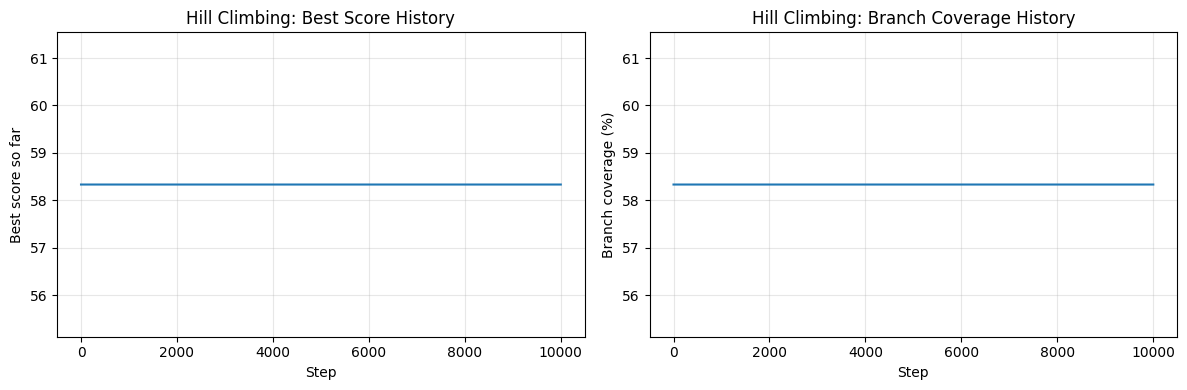

Best suite (test cases):
   1: (6.39, 0.25, 2.75)
   2: (2.23, 7.36, 6.77)
   3: (8.92, 0.87, 4.22)
   4: (0.3, 2.19, 5.05)
   5: (0.27, 1.99, 6.5)
   6: (5.45, 2.2, 5.89)
   7: (8.09, 0.06, 8.06)
   8: (6.98, 3.4, 1.55)
   9: (9.57, 3.37, 0.93)
  10: (0.97, 8.47, 6.04)
Best fitness score: 58.33
Branch coverage of best suite: 58.33%


In [81]:
import matplotlib.pyplot as plt

fitness_choice = 1

# Run hill climbing with branch-coverage fitness.
history_scores, history_suites, best_suite, best_score = hill_climbing(
    init_suite=seed_individual,
    fitness_id=fitness_choice, 
)

# Derive branch-coverage history from history_suites.
history_branch_coverage = [coverage_by_test_suite(suite) for suite in history_suites]

# Visualize both score change and branch-coverage change.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_scores)
axes[0].set_title("Hill Climbing: Best Score History")
axes[0].set_xlabel("Step")
axes[0].set_ylabel("Best score so far")
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_branch_coverage)
axes[1].set_title("Hill Climbing: Branch Coverage History")
axes[1].set_xlabel("Step")
axes[1].set_ylabel("Branch coverage (%)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Report final results.
final_branch_coverage = coverage_by_test_suite(best_suite)
print("Best suite (test cases):")
for i, (a, b, c) in enumerate(best_suite, start=1):
    print(f"  {i:2d}: ({a}, {b}, {c})")
print(f"Best fitness score: {best_score:.2f}")
print(f"Branch coverage of best suite: {final_branch_coverage:.2f}%")


### Genetic Algorithm (Population-based Search)

A genetic algorithm maintains a population of test suites and iteratively applies selection, crossover, and mutation so higher-fitness suites are more likely to produce better offspring.

## Search Results and Discussion

We analyze the resulting test suites and compare the strengths and limitations of the search algorithms.